# Decision Tree Classification with `rpart`

## Overview

Decision trees partition the feature space into rectangular regions using recursive binary splits. They are the foundation of random forests and gradient boosting, and are valuable for their interpretability even when outperformed by ensembles.

**Strengths:** Fully interpretable; handles mixed feature types natively; no scaling needed; captures non-linear and interaction effects automatically.

**Weaknesses:** High variance (small data changes produce very different trees); prone to overfitting without pruning; generally lower predictive performance than ensembles.

**Key parameters:**

| Parameter | What it controls | Typical range |
|---|---|---|
| `cp` | Complexity penalty — governs pruning | Cross-validate; start from 0 |
| `maxdepth` | Maximum tree depth | 3–10; shallower = more interpretable |
| `minsplit` | Min observations to attempt a split | 10–20 |
| `minbucket` | Min observations in a terminal node | 5–10 |

---

## Setup

In [2]:
library(tidyverse)
library(ggplot2)
library(rpart)          # recursive partitioning
library(rpart.plot)     # rpart.plot(), prp()
library(yardstick)      # metrics
library(patchwork)

set.seed(42)

n <- 500
tree_data <- tibble(
  nitrate     = rnorm(n, 3, 1.2),
  water_qual  = rnorm(n, 6, 1.5),
  distance_km = rexp(n, 0.4),
  elevation   = rnorm(n, 200, 80),
  habitat     = factor(sample(c("reference","restored","degraded"), n,
                              replace=TRUE, prob=c(.35,.35,.30)),
                       levels=c("reference","restored","degraded")),
  log_odds    = -1 + 0.6*water_qual - 0.7*nitrate - 0.3*distance_km +
                case_when(habitat=="reference"~0.8, habitat=="restored"~0.2,
                          habitat=="degraded"~ -0.9),
  present     = factor(rbinom(n, 1, plogis(log_odds)),
                       levels=c(0,1), labels=c("absent","present"))
)

train_idx  <- sample(n, 375)
train_data <- tree_data[train_idx,]
test_data  <- tree_data[-train_idx,]

Warning message:
"package 'rpart.plot' was built under R version 4.4.3"
Warning message:
"package 'yardstick' was built under R version 4.4.3"

Attaching package: 'yardstick'


The following object is masked from 'package:readr':

    spec


Warning message:
"package 'patchwork' was built under R version 4.4.3"


---

## Fit and Visualise a Decision Tree


Classification tree:
rpart(formula = present ~ nitrate + water_qual + distance_km + 
    elevation + habitat, data = train_data, method = "class", 
    parms = list(split = "gini"), control = rpart.control(cp = 0, 
        minsplit = 10, minbucket = 5, maxdepth = 10))

Variables actually used in tree construction:
[1] distance_km elevation   habitat     nitrate     water_qual 

Root node error: 165/375 = 0.44

n= 375 

          CP nsplit rel error  xerror     xstd
1  0.2606061      0   1.00000 1.00000 0.058258
2  0.0727273      1   0.73939 0.75758 0.055326
3  0.0424242      3   0.59394 0.71515 0.054501
4  0.0242424      4   0.55152 0.74545 0.055100
5  0.0181818      6   0.50303 0.73939 0.054985
6  0.0141414      7   0.48485 0.73939 0.054985
7  0.0121212     10   0.44242 0.73939 0.054985
8  0.0090909     18   0.34545 0.74545 0.055100
9  0.0060606     20   0.32727 0.71515 0.054501
10 0.0030303     23   0.30909 0.70909 0.054375
11 0.0000000     25   0.30303 0.70303 0.054247


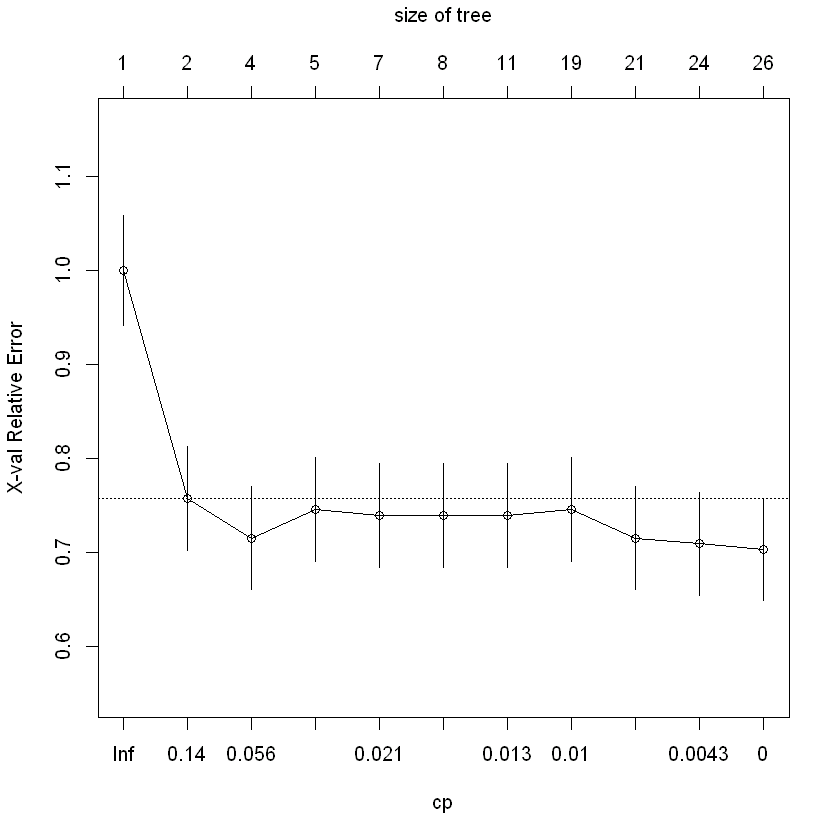

In [3]:
# Fit a full tree (cp=0: no pruning yet)
tree_full <- rpart(
  present ~ nitrate + water_qual + distance_km + elevation + habitat,
  data    = train_data,
  method  = "class",           # classification (use 'anova' for regression)
  parms   = list(split="gini"), # gini impurity (or 'information' for entropy)
  control = rpart.control(
    cp       = 0,     # grow full tree first; prune separately
    minsplit = 10,
    minbucket = 5,
    maxdepth = 10
  )
)

# ── Cross-validation plot to select cp ───────────────────────────────────────
plotcp(tree_full)
# x-axis: cp value; y-axis: cross-validated error
# Select the leftmost point within 1 SE of the minimum (1-SE rule)
printcp(tree_full)

---

## Pruning

Selected cp (1-SE rule): 0.04242


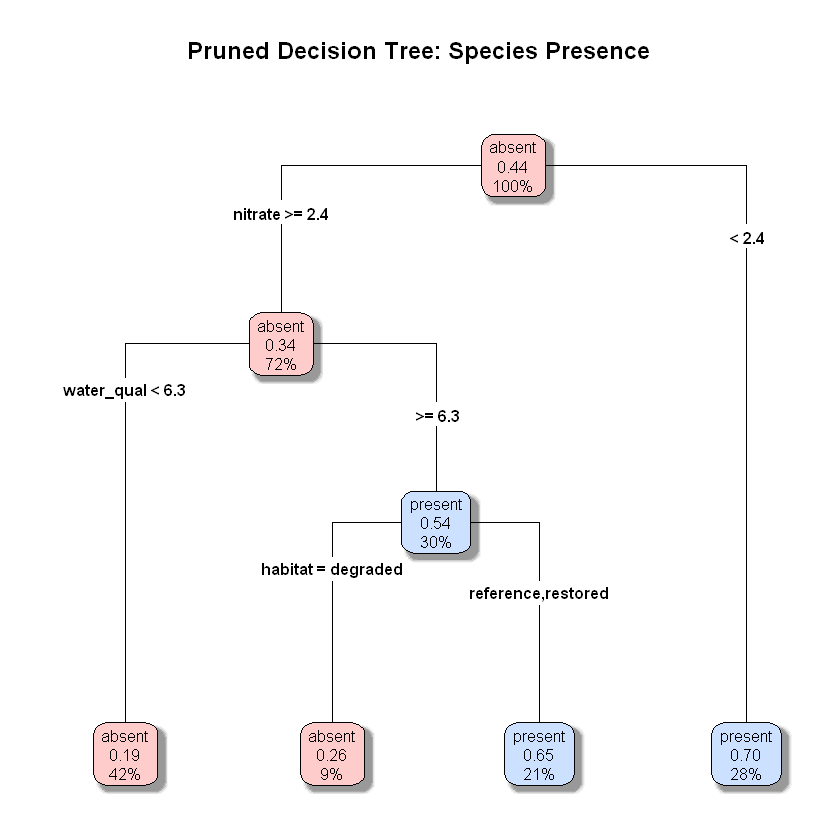

In [4]:
# Select cp using the 1-SE rule: sparsest model within 1 SE of minimum CV error
cp_table <- as_tibble(tree_full$cptable)
min_xerr  <- min(cp_table$xerror)
min_xstd  <- cp_table$xstd[which.min(cp_table$xerror)]
cp_1se    <- cp_table %>%
  filter(xerror <= min_xerr + min_xstd) %>%
  slice_max(CP) %>%
  pull(CP)

cat(sprintf("Selected cp (1-SE rule): %.5f\n", cp_1se))

# Prune to the selected cp
tree_pruned <- prune(tree_full, cp=cp_1se)

# ── Visualise the pruned tree ─────────────────────────────────────────────────
rpart.plot(
  tree_pruned,
  type    = 4,          # type 4: label at each node with variable name and split
  extra   = 106,        # show class probabilities + node %
  box.palette = c("#ffcccc","#cce0ff"),  # red=absent, blue=present
  shadow.col  = "gray60",
  main    = "Pruned Decision Tree: Species Presence",
  cex     = 0.8
)
# Each node shows: predicted class | P(present) | % of training data

---

## Evaluation and Variable Importance

# A tibble: 2 × 3
  .metric  .estimator .estimate
  <chr>    <chr>          <dbl>
1 accuracy binary         0.704
2 kap      binary         0.406
# A tibble: 1 × 3
  .metric .estimator .estimate
  <chr>   <chr>          <dbl>
1 roc_auc binary         0.688


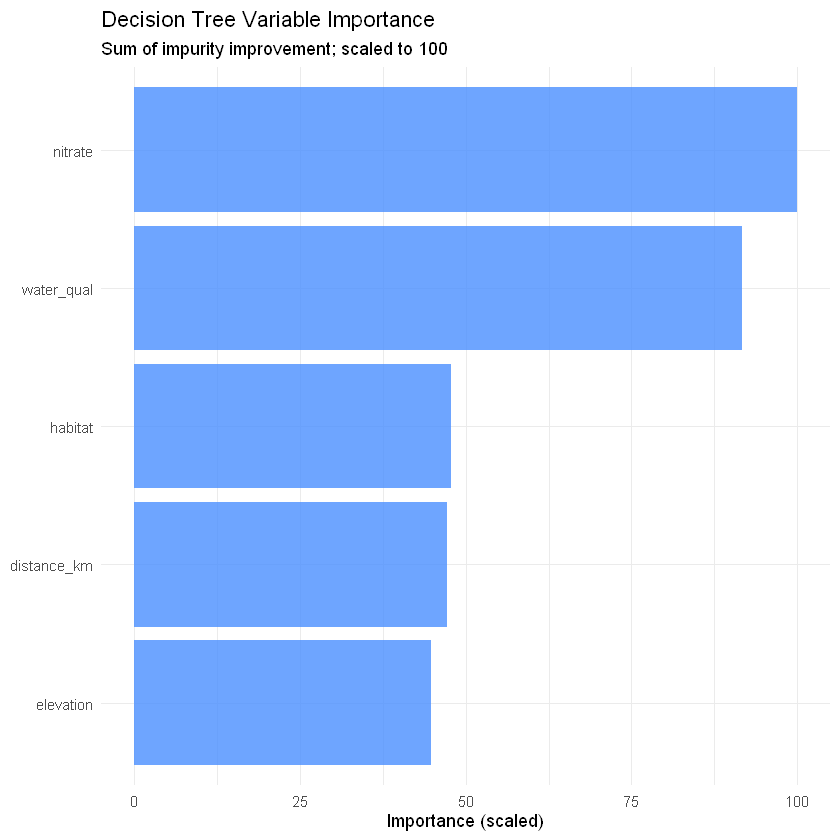

In [5]:
# Predict on test set
test_preds <- test_data %>%
  mutate(
    prob_present = predict(tree_pruned, newdata=test_data, type="prob")[,"present"],
    pred_class   = predict(tree_pruned, newdata=test_data, type="class")
  )

# Metrics
yardstick::metrics(test_preds, truth=present, estimate=pred_class) %>% print()
yardstick::roc_auc(test_preds, truth=present, prob_present,
                   event_level="second") %>% print()

# ── Variable importance ───────────────────────────────────────────────────────
# rpart variable importance: sum of improvement in gini impurity per variable
vi_df <- tibble(
  variable   = names(tree_full$variable.importance),
  importance = tree_full$variable.importance
) %>%
  mutate(importance_scaled = importance / max(importance) * 100) %>%
  arrange(desc(importance_scaled))

ggplot(vi_df, aes(x=importance_scaled,
                  y=fct_reorder(variable, importance_scaled))) +
  geom_col(fill="#4a8fff", alpha=0.8) +
  labs(title="Decision Tree Variable Importance",
       subtitle="Sum of impurity improvement; scaled to 100",
       x="Importance (scaled)", y=NULL) +
  theme_minimal()

---

## Common Pitfalls

**1. Plotting and interpreting an unpruned tree**  
An unpruned tree is overfit to the training data — its structure reflects noise, not signal. Always prune using `cp` selected by cross-validation (`plotcp()` → 1-SE rule) before interpreting the tree.

**2. Using a single decision tree as the final model for prediction**  
Single trees have high variance — small changes in training data produce very different trees. Use random forests or gradient boosting for prediction tasks. Single trees are primarily useful for interpretability and as teaching tools.

**3. Interpreting variable importance as a unique measure of importance**  
rpart variable importance is the total gain in Gini impurity improvement. It is biased toward variables with many possible split points (continuous variables vs. binary). For unbiased importance, use conditional importance from `party::ctree()` or permutation importance from random forests.

**4. Not setting a minimum node size**  
Without `minbucket`, trees can grow terminal nodes containing a single observation. Such nodes perfectly memorise training data and have zero predictive value. Always set `minsplit` and `minbucket`.

**5. Using default gini without considering entropy**  
For heavily imbalanced classes, entropy (`split="information"`) sometimes produces better-calibrated probability estimates than Gini. Check both when class imbalance is present.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*